<a href="https://colab.research.google.com/github/leesungyeon-dot/10thML/blob/week_2/2%EC%A3%BC%EC%B0%A8_%EB%B3%B5%EC%8A%B5%EA%B3%BC%EC%A0%9C_%EC%9D%B4%EC%84%B1%EC%97%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 사이킷런으로 수행하는 타이타닉 생존자 예측

타이나닉 탑승자 데이의 feature 정보이다.

1. Passengerid : 탑승자 데이터 일련번호
2. survived : 생존 여부, 0=사망, 1=생존
3. pclass : 티켓의 선실 등급, 1=일등석, 2=이등석, 3=삼등석
4. sex : 탑승자 성별
5. name : 탑승자 이름
6.Age : 탑승자 나이
7. sibsp : 같이 탑승한 형제자매 또는 배우자 인원 수
8. parch : 같이 탑승한 부모님 또는 어린이 인원 수
9. ticket : 티켓 번호
10. fare : 요금

11. cabin : 선실 번호
12. embarked : 중간 정착 항구 C=Cherbourg, Q=Queenstown, S=Southampton

In [5]:
import requests
import os

# URL for the Titanic training dataset from a public repository
data_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
file_name = 'titanic_train.csv'

# Download the file
response = requests.get(data_url)
if response.status_code == 200:
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f"'{file_name}' 다운로드 완료.")
else:
    print(f"'{file_name}' 다운로드 실패. 상태 코드: {response.status_code}")


'titanic_train.csv' 다운로드 완료.


In [6]:
titanic_df = pd.read_csv('titanic_train.csv')
print("데이터 로드 완료: 'titanic_train.csv'")

데이터 로드 완료: 'titanic_train.csv'


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# titanic_df = pd.read_csv('/content/drive/MyDrive/pymldg-rev/2장/titanic_train.csv')
# FileNotFoundError: [Errno 2] No such file or directory.
# Please check if 'titanic_train.csv' exists at '/content/drive/MyDrive/pymldg-rev/2장/'
# or ensure Google Drive is correctly mounted and the path is accurate.
# Once the file path is corrected or the file is uploaded, uncomment the line below.
# titanic_df = pd.read_csv('path/to/your/titanic_train.csv')

print('\n ### train 데이터 정보 ###  \n')
print(titanic_df.info())


 ### train 데이터 정보 ###  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [16]:
print('초기 데이터 세트 Null 값 갯수 ',titanic_df.isnull().sum().sum())
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('fillna() 함수 사용 후 데이터 세트 Null 값 갯수 ',titanic_df.isnull().sum().sum())

초기 데이터 세트 Null 값 갯수  0
fillna() 함수 사용 후 데이터 세트 Null 값 갯수  0


null 값 처리 :

Age의 경우는 평균, 나머지는 'N' 값으로 변경한 후, 다시 모든 cloumn에 Null 값이 없는지 확인

DataFrame()의 fillna() 함수를 사용해서 Null 값을 평균 또는 고정 값으로 변경

In [9]:
print('초기 데이터 세트 Null 값 갯수 ',titanic_df.isnull().sum().sum())
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print('fillna() 함수 사용 후 데이터 세트 Null 값 갯수 ',titanic_df.isnull().sum().sum())

초기 데이터 세트 Null 값 갯수  0
fillna() 함수 사용 후 데이터 세트 Null 값 갯수  0


/tmp/ipykernel_1019/883299899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)


In [11]:
# 문자열 feature인 sex, cabin, embarked를 확인해야함
print(' Sex 값 분포 :\n',titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n',titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n',titanic_df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [12]:
#N값이 많은 carbin의 경우 첫 알파벳만 추출해 재정리
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].value_counts())

Cabin
N    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


<Axes: xlabel='Sex', ylabel='Survived'>

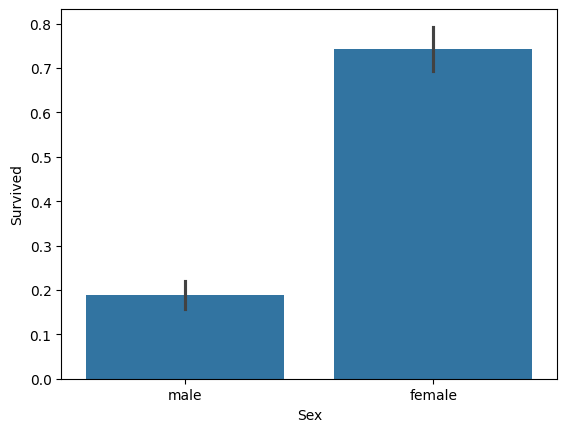

In [13]:
# 우선, 성별에 따른 생존자 수 비교
titanic_df.groupby(['Sex','Survived'])['Survived'].count()
#시각화
import seaborn as sns
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

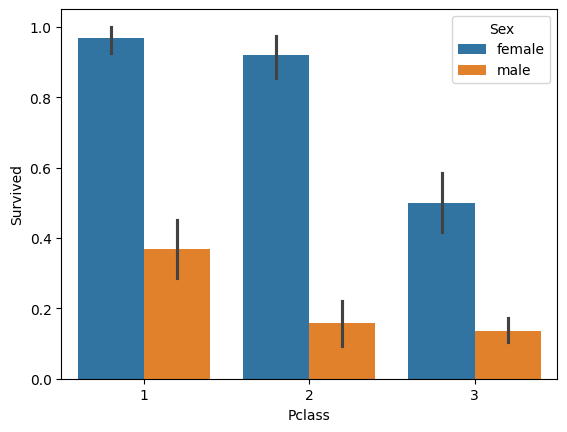

In [14]:
# 부에 따른 생존 확률 비교 - 객실 등급에 따라
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

남성의 경우 일등석의 생존 확률이 2,3등석보다 훨씬 높음.
여성의 경우 큰 차이는 없음

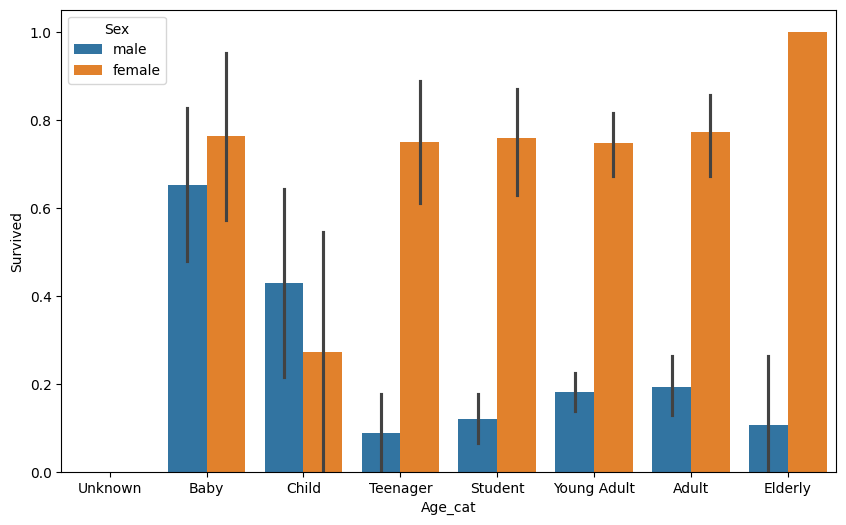

In [15]:
# 입력 age에 따라 구분값을 반환하는 함수 설정. DataFrame의 apply lambda식에 사용.
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    return cat

# 막대그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10,6))

#X축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정.
# get_category(X)는 입력값으로 'Age' 컬럼값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y = 'Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

**피마 인디언 당뇨병 예측**

dataset의 feature 정보
1. Pregnancies : 임신 횟수
2. Glucose : 포도당 부하 검사 수치
3. BloodPressure : 혈압(nm Hg)
4. SkinThickness : 팔 삼두근 뒤쪽의 피하지방 측정값(nm)
5. Insulin : 혈청 인슐린(mu U/ml)
6. BMI : 체질량지수(체중(kg)/(키(m))^2)
7. DiabetesPedigreeFunction : 당뇨 내력 가중치 값
8. Age : 나이
9. Outcome : Class 결정 값(0 or 1)

In [17]:
import requests
import os
import pandas as pd

# URL for the Pima Indian Diabetes dataset from a public repository (Kaggle dataset)
data_url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
file_name = 'pima_indian_diabetes.csv'

# Download the file
response = requests.get(data_url)
if response.status_code == 200:
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f"'{file_name}' 다운로드 완료.")
else:
    print(f"'{file_name}' 다운로드 실패. 상태 코드: {response.status_code}")

'pima_indian_diabetes.csv' 다운로드 완료.


In [18]:
pima_df = pd.read_csv('pima_indian_diabetes.csv')
print("데이터 로드 완료: 'pima_indian_diabetes.csv'")

print('\n ### 피마 인디언 당뇨병 데이터 정보 ###  \n')
print(pima_df.info())
print('\n ### 피마 인디언 당뇨병 데이터 상위 5행 ###  \n')
display(pima_df.head())

데이터 로드 완료: 'pima_indian_diabetes.csv'

 ### 피마 인디언 당뇨병 데이터 정보 ###  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

 ### 피마 인디언 당뇨병 데이터 상위 5행 ###  



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
print('피마 인디언 당뇨병 데이터 0 값 개수 확인:')
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    zeros_count = (pima_df[col] == 0).sum()
    print(f'{col}: {zeros_count} 개')

# 0 값을 각 컬럼의 평균으로 대체
# Outcome 컬럼은 Class 결정 값이므로 제외
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_features:
    pima_df[col] = pima_df[col].replace(0, pima_df[col].mean())

print('\n0 값을 평균으로 대체한 후 데이터 0 값 개수 확인:')
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    zeros_count = (pima_df[col] == 0).sum()
    print(f'{col}: {zeros_count} 개')

print('\n결측값 처리 후 pima_df 상위 5행:')
display(pima_df.head())

피마 인디언 당뇨병 데이터 0 값 개수 확인:
Glucose: 5 개
BloodPressure: 35 개
SkinThickness: 227 개
Insulin: 374 개
BMI: 11 개

0 값을 평균으로 대체한 후 데이터 0 값 개수 확인:
Glucose: 0 개
BloodPressure: 0 개
SkinThickness: 0 개
Insulin: 0 개
BMI: 0 개

결측값 처리 후 pima_df 상위 5행:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1


In [26]:
## 예측 모델 생성 및 get_clf_eval(), get_eval_by_threshold, precision_recall_curve_plot을 이용해 성능 평가

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 수정된 get_clf_eval() 함수
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(f'TN {confusion[0][0]}\t/ FP {confusion[0][1]}')
    print(f'FN {confusion[1][0]}\t/ TP {confusion[1][1]}')
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))

    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

# 피처 데이터 세트 X, 레이블 데이터 세트 y를 추출.
# 맨 끝이 Outcome 컬럼으로 레이블 값임. 컬럼 위치 -1을 이용해 추출
X = pima_df.iloc[:, :-1]
y = pima_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 156, stratify=y)

# 로지스틱 회귀로 학습,예측 및 평가 수행.
lr_clf = LogisticRegression()
lr_clf.fit(X_train , y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test , pred, pred_proba)

오차 행렬
TN 89	/ FP 11
FN 19	/ TP 35
정확도: 0.8052, 정밀도: 0.7609, 재현율: 0.6481, F1: 0.7000, AUC:0.8461


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


위에 데이터셋 적용이 안되어서 지피티의 도움을 받음

전체 데이터의 65%가 negative이므로 재현율 성능에 더 초점을 두는 구조라고함

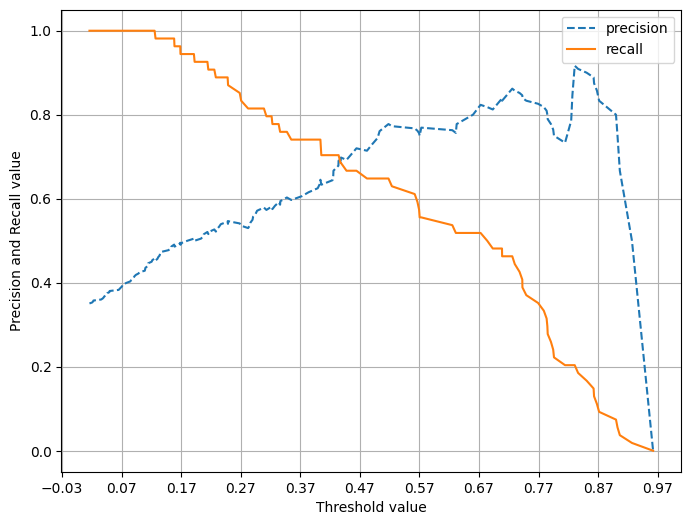

In [27]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)